In [4]:
# from pathlib import Path
import cftime
import cartopy.crs as ccrs
import cartopy.geodesic
import cartopy.feature as cf
import dask
import healpix as hp
from IPython.display import clear_output
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.animation
import numpy as np
import pandas as pd
import xarray as xr
import easygems.healpix as egh
import intake
from pyflextrkr.smooth_trajectory import smooth_trajectory

import requests
from io import BytesIO

mpl.rcParams['figure.dpi'] = 72  # Set figure resolution to reduce file size
# Use for .mp4 video:
plt.rcParams["animation.html"] = "html5"
# Use for javascript animation:
# plt.rcParams["animation.html"] = "jshtml"

In [5]:
# Load the NERSC catalog
current_location = "UK"
cat = intake.open_catalog("https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")[current_location]

In [6]:
pd.DataFrame(cat["um_glm_n2560_RAL3p3"].describe()["user_parameters"])

,name,description,type,allowed,default
0,time,time resolution of the dataset,str,"[PT1H, PT3H]",PT1H
1,zoom,zoom resolution of the dataset,int,"[10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]",8


### Load HEALPix Data into a DataSet
Two simulations have been tracked. You can choose the N2560 with `zoom` level 10 [(~6km)](https://easy.gems.dkrz.de/Processing/healpix/index.html#healpix-spatial-resolution) or the N1280 with zoom level 9. The datasets containhourly OLR & precipitation, which was used in the MCS tracking.

In [7]:
#N2560
#runid='um_glm_n2560_RAL3p3'
runid='um_glm_n2560_RAL3p3'

dshp = cat[runid](zoom=10, time='PT3H').to_dask().pipe(egh.attach_coords)
dshp


/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 53TB
Dimensions:   (time: 3497, pressure: 25, cell: 12582912)
Coordinates:
  * pressure  (pressure) int64 200B 1 5 10 20 30 50 ... 875 900 925 950 975 1000
  * time      (time) datetime64[ns] 28kB 2020-01-20 ... 2021-04-01
    crs       int64 8B 0
  * cell      (cell) int64 101MB 0 1 2 3 ... 12582908 12582909 12582910 12582911
    lat       (cell) float64 101MB 0.0373 0.0746 0.0746 ... -0.0746 -0.0373
    lon       (cell) float64 101MB 45.0 45.04 44.96 45.0 ... 315.0 315.0 315.0
Data variables: (12/14)
    cli       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    clw       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    hur       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    hus       (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    qg        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    qr        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    ...        ...
    ua        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    va        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    wa        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    zg        (time, pressure, cell) float32 4TB dask.array<chunksize=(1, 1, 1048576), meta=np.ndarray>
    orog      (cell) float64 101MB dask.array<chunksize=(98304,), meta=np.ndarray>
    sftlf     (cell) float64 101MB dask.array<chunksize=(98304,), meta=np.ndarray>
Attributes:
    Met Office DYAMOND3 simulations:  A group of experiments have been conduc...
    bounds:                           {'lower_left_lat': -90, 'lower_left_lon...
    latitiude_convention:             [-90, 90]
    longitude_convention:             [0, 360]
    regional:                         False
    simulation:                       glm.n2560_RAL3p3
    simulation_description:           The MetUM uses a regular lat-lon grid, ...

In [8]:
#Get timestep of the data in hours
dt=dshp.time.values[1].astype('datetime64[h]')-dshp.time.values[0].astype('datetime64[h]')
dt

np.timedelta64(3,'h')

In [9]:
trop_lat_idx = (dshp.lat.values < 30) & (dshp.lat.values > -30)

In [10]:
w500lazy = dshp.wa.sel(pressure=500, time=slice('2020-03-01 00:00', '2020-04-01 00:00')).isel(cell=trop_lat_idx)

In [11]:
w500 = w500lazy.compute()

### Load MCS Tracking Data

In [12]:
# MCS data

if runid=='um_glm_n2560_RAL3p3':
  maskdir = "https://hackathon-o.s3-ext.jc.rl.ac.uk/sim-data/analysis/PyFLEXTRKR/um_glm_n2560_RAL3p3/mcstracking/mcs_mask_hp10_20200201.0000_20210301.0000.zarr"
  statsdir = "https://hackathon-o.s3-ext.jc.rl.ac.uk/sim-data/analysis/PyFLEXTRKR/um_glm_n2560_RAL3p3/stats/"
elif runid=='um_glm_n1280_CoMA9_TBv1p2':
  maskdir = "https://hackathon-o.s3-ext.jc.rl.ac.uk/sim-data/analysis/PyFLEXTRKR/um_glm_n1280_CoMA9_TBv1p2_catalog_par/mcstracking/mcs_mask_hp9_20200201.0000_20210301.0000.zarr"
  statsdir = "https://hackathon-o.s3-ext.jc.rl.ac.uk/sim-data/analysis/PyFLEXTRKR/um_glm_n1280_CoMA9_TBv1p2_catalog_par/stats/"
else:
  print(f"Error: Dataset {runid} not available.")

# MCS track statistics file
stats_file = f"{statsdir}mcs_tracks_final_20200201.0000_20210301.0000.nc"
stats_file

'https://hackathon-o.s3-ext.jc.rl.ac.uk/sim-data/analysis/PyFLEXTRKR/um_glm_n2560_RAL3p3/stats/mcs_tracks_final_20200201.0000_20210301.0000.nc'

In [13]:
response = requests.get(stats_file, stream=True)

# chunks_tracks = {'tracks': 1000, 'times': 400}
chunks_tracks = None

# Open the dataset
dstracks = xr.open_dataset(
    BytesIO(response.content), 
    chunks=chunks_tracks,
    mask_and_scale=True)

# # Each seperate file for each year defines its own index for tracks. Re-index with a global index.
# dstracks["tracks"] = np.arange(0, dstracks.dims["tracks"], 1, dtype=int)

In [14]:
# The times have a small offset from the exact times -- e.g. 34500 ns off. Correct this.
# This mostly applies to the satellite data
def round_times_to_nearest_second(dstracks, fields):
    def remove_time_incaccuracy(t):
        # To make this an array operation, you have to use the ns version of datetime64, like so:
        return (np.round(t.astype(int) / 1e9) * 1e9).astype("datetime64[ns]")

    for field in fields:
        dstracks[field].load()
        tmask = ~np.isnan(dstracks[field].values)
        dstracks[field].values[tmask] = remove_time_incaccuracy(
            dstracks[field].values[tmask]
        )

In [15]:
round_times_to_nearest_second(dstracks, ['base_time', 'start_basetime', 'end_basetime'])

In [16]:
dstracks

<xarray.Dataset> Size: 40GB
Dimensions:                  (tracks: 39340, times: 650, mergers: 50, nmaxpf: 3)
Coordinates:
  * tracks                   (tracks) int64 315kB 0 1 2 3 ... 39337 39338 39339
  * times                    (times) int64 5kB 0 1 2 3 4 ... 645 646 647 648 649
  * mergers                  (mergers) int64 400B 0 1 2 3 4 5 ... 45 46 47 48 49
  * nmaxpf                   (nmaxpf) int64 24B 0 1 2
Data variables: (12/63)
    track_duration           (tracks) int32 157kB ...
    start_status             (tracks) float64 315kB ...
    end_status               (tracks) float64 315kB ...
    start_basetime           (tracks) datetime64[ns] 315kB 2020-02-01 ... 202...
    end_basetime             (tracks) datetime64[ns] 315kB 2020-02-02T14:00:0...
    start_split_cloudnumber  (tracks) float64 315kB ...
    ...                       ...
    pf_mcsstatus             (tracks, times) float64 205MB ...
    movement_distance        (tracks, times) float32 102MB ...
    movement_speed           (tracks, times) float32 102MB ...
    movement_theta           (tracks, times) float32 102MB ...
    movement_distance_x      (tracks, times) float32 102MB ...
    movement_distance_y      (tracks, times) float32 102MB ...
Attributes: (12/21)
    Title:                        Statistics of each MCS track
    Institution:                  Pacific Northwest National Laboratory
    Contact:                      Zhe Feng, zhe.feng@pnnl.gov
    Created_on:                   Sat May 10 21:18:00 2025
    startdate:                    20200201.0000
    enddate:                      20210301.0000
    ...                           ...
    MCS_PF_majoraxis_thresh:      0
    MCS_PF_duration_thresh:       4
    PF_PF_min_majoraxis_thresh:   20
    mcs_min_rainvol_thresh:       20000
    mcs_volrain_duration_thresh:  1.0
    max_speed_thresh:             50

### Selecting tracks

In [17]:
# Or access tracks based on their location:
# N.B. force a load of meanlat.
dstracks.meanlat.load()
dstracks.meanlon.load()


<xarray.DataArray 'meanlon' (tracks: 39340, times: 650)> Size: 102MB
array([[ -96.431335,  -95.5139  ,  -98.070175, ...,         nan,
                nan,         nan],
       [ -44.915924,  -44.704193,  -40.058064, ...,         nan,
                nan,         nan],
       [ -74.81724 ,  -74.144615,  -72.995186, ...,         nan,
                nan,         nan],
       ...,
       [ 101.35    ,  101.19651 ,  101.12187 , ...,         nan,
                nan,         nan],
       [-166.45055 , -166.89468 , -166.63147 , ...,         nan,
                nan,         nan],
       [ -27.46    ,  -28.857224,  -27.960432, ...,         nan,
                nan,         nan]], dtype=float32)
Coordinates:
  * tracks   (tracks) int64 315kB 0 1 2 3 4 5 ... 39335 39336 39337 39338 39339
  * times    (times) int64 5kB 0 1 2 3 4 5 6 7 ... 643 644 645 646 647 648 649
Attributes:
    long_name:  Mean longitude of a feature
    units:      degrees_east

In [51]:
mcs_meanlat = np.nanmean(dstracks.meanlat.values, axis=1)
tropics_mask = (mcs_meanlat < 30) & (mcs_meanlat > -30)
time_mask = (dstracks.start_basetime > pd.Timestamp('2020-03-02')) & (dstracks.start_basetime < pd.Timestamp('2020-03-30'))

In [19]:
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance in kilometers between two points 
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(np.deg2rad, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.asin(np.sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    return c * r

In [20]:
z = 10

In [23]:
lon, lat = hp.pix2ang(2**z, np.arange(12 * 4**z), nest=True, lonlat=True)
lon = lon[(lat < 30) & (lat > -30)]
lat = lat[(lat < 30) & (lat > -30)]


In [30]:
nupdraft = np.full((tropics_mask.sum(), 3), np.nan)

In [31]:
tropics_mask.sum()

np.int64(34429)

In [52]:
# Each track can then be looped over using e.g.:
n = 100
for i, track_id in enumerate(dstracks.tracks.values[tropics_mask & time_mask][:n]):  # Just get first n.
    print(f'{i + 1}/{tropics_mask.sum()}')
    track = dstracks.sel(tracks=track_id)
    dur = track.track_duration.values.item()
    first_time = pd.Timestamp(track.start_basetime.values.item()) - pd.Timedelta(hours=3)
    end_time = pd.Timestamp(track.start_basetime.values.item()) + pd.Timedelta(hours=3)
    times = pd.date_range(first_time, end_time, freq='3h')
    print(len(times))
    mlats = np.hstack([track.meanlat.values[0], track.meanlat.values[0], track.meanlat.values[3]])
    #print(len(lats))
    mlons = np.hstack([track.meanlon.values[0], track.meanlon.values[0], track.meanlon.values[3]])
    for j, (t, mlat, mlon) in enumerate(zip(times, mlats, mlons)):
        idx = haversine(lon, lat, mlon, mlat) < 500
        #print(t)
        nupdraft[i, j] = (w500.sel(time=t, cell=idx, method='nearest').values > 2).sum()



1/34429
3
2/34429
3


/tmp/ipykernel_541/311563288.py:13: RuntimeWarning: invalid value encountered in arcsin
  c = 2 * np.asin(np.sqrt(a))


3/34429
3
4/34429
3
5/34429
3
6/34429
3
7/34429
3
8/34429
3
9/34429
3
10/34429
3
11/34429
3
12/34429
3
13/34429
3
14/34429
3
15/34429
3
16/34429
3
17/34429
3
18/34429
3
19/34429
3
20/34429
3
21/34429
3
22/34429
3
23/34429
3
24/34429
3
25/34429
3
26/34429
3
27/34429
3
28/34429
3
29/34429
3
30/34429
3
31/34429
3
32/34429
3
33/34429
3
34/34429
3
35/34429
3
36/34429
3
37/34429
3
38/34429
3
39/34429
3
40/34429
3
41/34429
3
42/34429
3
43/34429
3
44/34429
3
45/34429
3
46/34429
3
47/34429
3
48/34429
3
49/34429
3
50/34429
3
51/34429
3
52/34429
3
53/34429
3
54/34429
3
55/34429
3
56/34429
3
57/34429
3
58/34429
3
59/34429
3
60/34429
3
61/34429
3
62/34429
3
63/34429
3
64/34429
3
65/34429
3
66/34429
3
67/34429
3
68/34429
3
69/34429
3
70/34429
3
71/34429
3
72/34429
3
73/34429
3
74/34429
3
75/34429
3
76/34429
3
77/34429
3
78/34429
3
79/34429
3
80/34429
3
81/34429
3
82/34429
3
83/34429
3
84/34429
3
85/34429
3
86/34429
3
87/34429
3
88/34429
3
89/34429
3
90/34429
3
91/34429
3
92/34429
3
93/34429
3
94/344

Text(0.5, 1.0, 'MCS precursor/tracked # updrafts (500 km radius)\n100 tropical MCSs\nUM 5km RAL3.3')

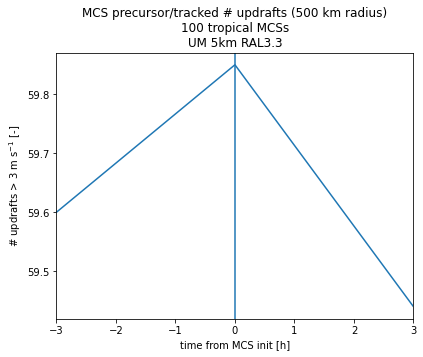

In [53]:
plt.plot(np.array([-3, 0, 3]), np.nanmean(nupdraft, axis=0))
plt.xlim(-3, 3)
#plt.ylim(61, 63)
plt.axvline(x=0)
plt.xlabel('time from MCS init [h]')
plt.ylabel('# updrafts > 3 m s$^{-1}$ [-]')
plt.title(f'MCS precursor/tracked # updrafts (500 km radius)\n{n} tropical MCSs\nUM 5km RAL3.3')


In [48]:
w500.sel(time=pd.Timesamp('2020-01-01, method='nearest').time.values

np.datetime64('2020-03-01T00:00:00.000000000')

In [47]:
times

DatetimeIndex(['2020-02-01 02:00:00', '2020-02-01 05:00:00',
               '2020-02-01 08:00:00'],
              dtype='datetime64[ns]', freq='3h')

### Individual track properties

In [41]:
# Select a track.
track = dstracks.sel(tracks=50)
track

<xarray.Dataset> Size: 1MB
Dimensions:                  (times: 650, mergers: 50, nmaxpf: 3)
Coordinates:
    tracks                   int64 8B 50
  * times                    (times) int64 5kB 0 1 2 3 4 ... 645 646 647 648 649
  * mergers                  (mergers) int64 400B 0 1 2 3 4 5 ... 45 46 47 48 49
  * nmaxpf                   (nmaxpf) int64 24B 0 1 2
Data variables: (12/63)
    track_duration           int32 4B ...
    start_status             float64 8B ...
    end_status               float64 8B ...
    start_basetime           datetime64[ns] 8B 2020-02-01T06:00:00
    end_basetime             datetime64[ns] 8B 2020-02-01T20:00:00
    start_split_cloudnumber  float64 8B ...
    ...                       ...
    pf_mcsstatus             (times) float64 5kB ...
    movement_distance        (times) float32 3kB ...
    movement_speed           (times) float32 3kB ...
    movement_theta           (times) float32 3kB ...
    movement_distance_x      (times) float32 3kB ...
    movement_distance_y      (times) float32 3kB ...
Attributes: (12/21)
    Title:                        Statistics of each MCS track
    Institution:                  Pacific Northwest National Laboratory
    Contact:                      Zhe Feng, zhe.feng@pnnl.gov
    Created_on:                   Tue May 13 20:26:11 2025
    startdate:                    20200201.0000
    enddate:                      20210301.0000
    ...                           ...
    MCS_PF_majoraxis_thresh:      0
    MCS_PF_duration_thresh:       4
    PF_PF_min_majoraxis_thresh:   20
    mcs_min_rainvol_thresh:       20000
    mcs_volrain_duration_thresh:  1.0
    max_speed_thresh:             50

In [42]:
# Access some of the track's properties:
# Scalars can be accessed using:
duration = track.track_duration.values.item()  # `.values.item()` unpacks the value into an int (in this case).
print(f'track_duration: {duration*dt}')
# For times, it is useful to convert from a np.datetime64[ns] to a pandas Timestamp object or native datetime object:
start_basetime = pd.Timestamp(track.start_basetime.values.item()).to_pydatetime()
print(f'start_basetime: {start_basetime}')
end_basetime = pd.Timestamp(track.end_basetime.values.item()).to_pydatetime()
print(f'end_basetime: {end_basetime}')

# Lifetime values can be accessed:
# Note, e.g. area values are nan after the duration of the track:
print(f'area (full): {track.area.values}')
# Slice based on duration:
print(f'area (sliced): {track.area.values[:duration]}')

track_duration: 15 hours
start_basetime: 2020-02-01 06:00:00
end_basetime: 2020-02-01 20:00:00
area (full): [ 93500. 149200. 183700. 154400. 160800. 148200. 136300. 130700. 104800.
  31300.  29300.  26100.  15700.  12100.   1400.     nan     nan     nan
     nan     nan     nan     nan     nan     nan     nan     nan     nan
     nan     nan     nan     nan     nan     nan     nan     nan     nan
     nan     nan     nan     nan     nan     nan     nan     nan     nan
     nan     nan     nan     nan     nan     nan     nan     nan     nan
     nan     nan     nan     nan     nan     nan     nan     nan     nan
     nan     nan     nan     nan     nan     nan     nan     nan     nan
     nan     nan     nan     nan     nan     nan     nan     nan     nan
     nan     nan     nan     nan     nan     nan     nan     nan     nan
     nan     nan     nan     nan     nan     nan     nan     nan     nan
     nan     nan     nan     nan     nan     nan     nan     nan     nan
     nan     nan

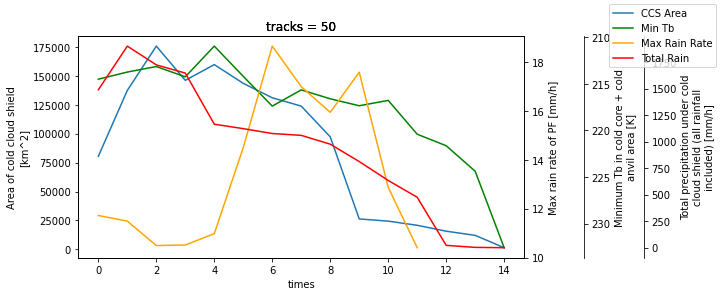

In [43]:
# Plot multiple variables for this track

fig, ax1 = plt.subplots(figsize=(8, 4))
track.ccs_area.plot.line(ax=ax1, label='CCS Area')

ax2 = ax1.twinx()
track.corecold_mintb.plot(ax=ax2, color='green', label='Min Tb')
ax2.spines['right'].set_position(('outward', 60))  # Move the third y-axis to the right
ax2.invert_yaxis()

ax3 = ax1.twinx()
track.pf_maxrainrate.isel(nmaxpf=0).plot(ax=ax3, color='orange', label='Max Rain Rate')
ax3.set_title('')

ax4 = ax1.twinx()
track.total_rain.plot(ax=ax4, color='red', label='Total Rain')
ax4.spines['right'].set_position(('outward', 120))  # Move the third y-axis to the right

fig.legend()

In [44]:
# mergers data are 2D fields (with -9999 indicating no values for merger number N):
track.merge_cloudnumber.values[:duration, :]

array([[ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan,  nan,  nan],
       [201.,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan,  nan,  nan],
       [ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
         nan,  nan,  n

In [45]:
# Similarly for PF data (with nan indicating no value):
track.pf_rainrate.values[:duration, :]

array([[4.6209683,       nan,       nan],
       [4.239478 ,       nan,       nan],
       [4.7923155, 4.1992674, 2.9875736],
       [5.2764945, 4.00083  , 3.7460022],
       [6.150722 , 2.8337011,       nan],
       [6.22108  ,       nan,       nan],
       [5.9906588,       nan,       nan],
       [5.73486  ,       nan,       nan],
       [6.529345 ,       nan,       nan],
       [6.9881487,       nan,       nan],
       [5.7187395,       nan,       nan],
       [5.294404 ,       nan,       nan],
       [      nan,       nan,       nan],
       [      nan,       nan,       nan],
       [      nan,       nan,       nan]], dtype=float32)

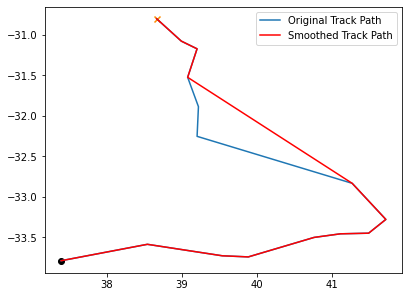

In [46]:
# A simple plot of the track's position can be made using:
plt.scatter(track.meanlon.values[0], track.meanlat.values[0], marker='o', color='k')  # Start point.
plt.scatter(track.meanlon.values[duration - 1], track.meanlat.values[duration - 1], marker='x', color='darkorange')  # End point.
# Plot the track's path:
plt.plot(track.meanlon.values, track.meanlat.values, label='Original Track Path')
# Smooth the trajectory using the `smooth_trajectory` function:
time_resolution = dstracks.attrs['time_resolution_hour']
max_speed_kmh = 100
lon_s, lat_s = smooth_trajectory(track.meanlon.values, track.meanlat.values, max_speed_kmh=max_speed_kmh, time_step_h=time_resolution)
plt.plot(lon_s, lat_s, color='red', label='Smoothed Track Path')
plt.legend()

In [47]:
def add_ccs_area_swath(ax, track, n_points=20):
    """Adds an area swath of the cold cloud system area, treating each CCS as a circle."""
    try:
        # N.B. these are optional dependencies.
        import shapely.geometry
        import shapely.ops
    except ImportError:
        print('shapely not installed')
        return
    duration = track.track_duration.values.item()
    time_indices = range(duration)
    
    # geoms will contain all the circles.
    geoms = []
    for i in time_indices:
        lon = track.meanlon.values[i]
        lat = track.meanlat.values[i]
        radius = np.sqrt(track.ccs_area.values[i] / np.pi) * 1e3
        circle_points = cartopy.geodesic.Geodesic().circle(
            lon=lon, lat=lat, radius=radius, n_samples=n_points, endpoint=False
        )
        geom = shapely.geometry.Polygon(circle_points)
        geoms.append(geom)
    # Combine all the circles into a CCS swath.
    full_geom = shapely.ops.unary_union(geoms)
    ax.add_geometries(
        (full_geom,),
        crs=cartopy.crs.PlateCarree(),
        facecolor="none",
        edgecolor="royalblue",
        linewidth=2,
    )

In [48]:
extent = track.meanlon.min().item() - 10, track.meanlon.max().item() + 10, track.meanlat.min().item() - 10, track.meanlat.max().item() + 10

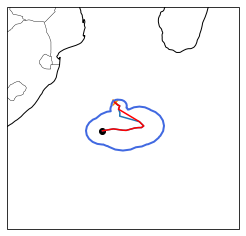

In [49]:
# Nicer figure using cartopy projections and showing a circle based on the CCS area.
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
fig.set_size_inches((8, 4))
ax.coastlines()
ax.add_feature(cf.BORDERS, linewidth=0.4)
ax.scatter(track.meanlon.values[0], track.meanlat.values[0], marker='o', color='k')
ax.scatter(track.meanlon.values[duration - 1], track.meanlat.values[duration - 1], marker='x', color='darkorange')
ax.plot(track.meanlon.values, track.meanlat.values)
ax.plot(lon_s, lat_s, color='red')
add_ccs_area_swath(ax, track)
buffer = 10
extent = track.meanlon.min().item() - buffer, track.meanlon.max().item() + buffer, track.meanlat.min().item() - buffer, track.meanlat.max().item() + buffer
ax.set_extent(extent)

### Group properties of tracks

Group properties for lots of tracks can be easily calculated by accessing the fields on an `xarray.Dataset` that contains many tracks.

In [50]:
# mean track duration:
dstracks.track_duration.values.mean()

np.float64(25.003281647386988)

In [51]:
# Same thing using xarray:
dstracks.track_duration.mean().values.item()

25.003281647386988

In [52]:
# Tropical duration:
dstracks_tropical.track_duration.values.mean()

np.float64(24.573363559081894)

In [53]:
# Mean area for each track:
# `np.nanX` functions are useful for naturally dealing with the missing data.
mean_areas = np.nanmean(dstracks.ccs_area.values, axis=1)

(array([   0.,   70.,  847., 1945., 2271., 1992., 1834., 1630., 1363.,
        1139., 1031.,  861.,  732.,  650.,  635.,  508.,  506.,  436.,
         392.,  348.,  310.,  263.,  235.,  225.,  239.,  225.,  194.,
         170.,  157.,  159.,  161.,  127.,  112.,  127.,  121.,  108.,
         103.,   91.,   81.,   86.,   90.,   88.,   65.,   77.,   70.,
          61.,   54.,   63.,   64.,   57.,   60.,   55.,   44.,   51.,
          39.,   44.,   39.,   34.,   37.,   34.,   25.,   38.,   27.,
          28.,   36.,   24.,   25.,   23.,   20.,   23.,   14.,   22.,
          24.,   22.,   10.,   19.,   19.,   17.,   11.,   18.,   14.,
           7.,   13.,   15.,   14.,   14.,    9.,    8.,   10.,   12.,
          10.,   10.,   13.,    6.,    8.,    9.,    4.,    4.,    5.,
           5.]),
 array([      0.,   10000.,   20000.,   30000.,   40000.,   50000.,
          60000.,   70000.,   80000.,   90000.,  100000.,  110000.,
         120000.,  130000.,  140000.,  150000.,  160000.,  170000.

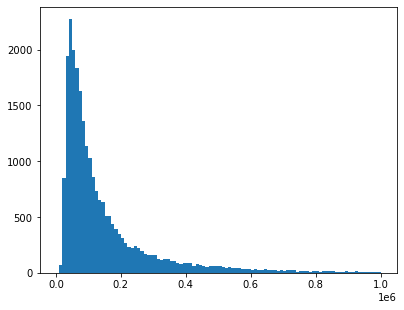

In [54]:
plt.hist(mean_areas, bins=np.linspace(0, 1e6, 101))

In [55]:
# Same thing using xarray:
xr_mean_areas = dstracks.ccs_area.mean(dim='times', skipna=True).values

In [56]:
(mean_areas == xr_mean_areas).all()

np.False_

## Accessing pixel-level data

Pixel-level data is stored separately from the MCS tracks data. These files contain the mcs_mask field, which is area covered by the MCS and can be linked to a given track (see below).

In [57]:
# Read MCS mask data:
#dsmask = xr.open_dataset(
dsmask = xr.open_zarr(
    maskdir,
    chunks={},
    # mask_and_scale=False,
)
dsmask

<xarray.Dataset> Size: 238GB
Dimensions:   (cell: 3145728, time: 9456)
Coordinates:
  * cell      (cell) int64 25MB 0 1 2 3 4 ... 3145724 3145725 3145726 3145727
    lat       (cell) float64 25MB dask.array<chunksize=(262144,), meta=np.ndarray>
    lon       (cell) float64 25MB dask.array<chunksize=(262144,), meta=np.ndarray>
  * time      (time) datetime64[ns] 76kB 2020-02-01 ... 2021-02-28T23:00:00
Data variables:
    mcs_mask  (time, cell) float64 238GB dask.array<chunksize=(24, 262144), meta=np.ndarray>

In [58]:
pd.Timestamp(dshp.time.values[0]).year

2020

In [59]:
pd.Timestamp(dsmask.time.values[0]).year

2020

In [60]:
# Convert time components from datasets to deal with different calendars
hp_times = [(pd.Timestamp(t).year, pd.Timestamp(t).month, 
               pd.Timestamp(t).day, pd.Timestamp(t).hour) for t in dshp.time.values]
mask_times = [(pd.Timestamp(t).year, pd.Timestamp(t).month, 
               pd.Timestamp(t).day, pd.Timestamp(t).hour) 
              for t in dsmask.time.values]

# Find matching indices
matching_indices = [i for i, t in enumerate(hp_times) if t in set(mask_times)]
# Select using indices
dshp_subset = dshp.isel(time=matching_indices)
# Verify number of timestamps
print(f"Original HEALPix time count: {dshp.time.size}")
print(f"Matching times found: {len(matching_indices)}")
print(f"dsmask time count: {dsmask.time.size}")

Original HEALPix time count: 10489
Matching times found: 9456
dsmask time count: 9456


In [61]:
# Create a new dsmask with the time coordinate from dshp_subset
dsmask_ = dsmask.copy()

# Replace the time coordinate with the matching times from dshp_subset
# This must maintain the same order as in the original dsmask
dsmask_ = dsmask_.assign_coords(time=dshp_subset.time.values)

# Combine the datasets
ds = xr.merge([dshp_subset, dsmask_], combine_attrs='drop_conflicts')

# Rechunk the dataset to match the mask
ds = ds.chunk(dict(dsmask_.chunks))
ds

<xarray.Dataset> Size: 3TB
Dimensions:   (cell: 3145728, time: 9456)
Coordinates:
  * cell      (cell) int64 25MB 0 1 2 3 4 ... 3145724 3145725 3145726 3145727
    crs       float64 8B nan
  * time      (time) datetime64[ns] 76kB 2020-02-01 ... 2021-02-28T23:00:00
    lat       (cell) float64 25MB dask.array<chunksize=(262144,), meta=np.ndarray>
    lon       (cell) float64 25MB dask.array<chunksize=(262144,), meta=np.ndarray>
Data variables: (12/27)
    clivi     (time, cell) float32 119GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    clt       (time, cell) float32 119GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    clwvi     (time, cell) float32 119GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    hflsd     (time, cell) float32 119GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    hfssd     (time, cell) float32 119GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    huss      (time, cell) float32 119GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    ...        ...
    sftlf     (cell) float64 25MB dask.array<chunksize=(262144,), meta=np.ndarray>
    tas       (time, cell) float32 119GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    ts        (time, cell) float32 119GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    uas       (time, cell) float32 119GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    vas       (time, cell) float32 119GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    mcs_mask  (time, cell) float64 238GB dask.array<chunksize=(24, 262144), meta=np.ndarray>

Text(0.5, 1.0, '2020-02-01 00:00')

<Figure size 460.8x345.6 with 0 Axes>

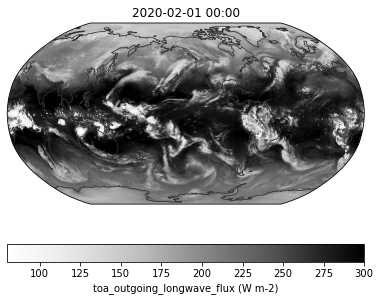

In [62]:
# Quick plot of global OLR
im = egh.healpix_show(ds.isel(time=0).rlut, vmin=80, vmax=300, cmap='Greys')
plt.colorbar(im, label=f"{ds.rlut.attrs['long_name']} ({ds.rlut.attrs['units']})", orientation='horizontal')
time_str = ds.time.isel(time=0).dt.strftime("%Y-%m-%d %H:%M").values.item()
plt.title(time_str)

Text(0.5, 1.0, '2020-02-01 00:00')

<Figure size 460.8x345.6 with 0 Axes>

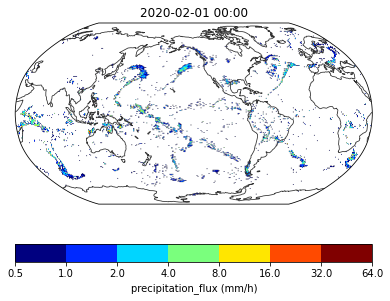

In [63]:
# Quick plot of global precipitation
levels_pr = [0.5,1,2,4,8,16,32,64]
cmap = mpl.colormaps.get_cmap('jet')
norm = mpl.colors.BoundaryNorm(boundaries=levels_pr, ncolors=cmap.N)
# Precipitation
pcp_convert=3600 
_pr = ds.isel(time=0).pr * pcp_convert # Convert unit from kg/m^2/s to mm/hr, if you use a different model check the units of your precip output 
_pr = _pr.where(_pr >= np.min(levels_pr), np.nan)

im = egh.healpix_show(_pr, norm=norm, cmap=cmap)
plt.colorbar(im, label=f"{ds.pr.attrs['long_name']} (mm/h)", orientation='horizontal')
time_str = ds.time.isel(time=0).dt.strftime("%Y-%m-%d %H:%M").values.item()
plt.title(time_str)

## Linking tracks to pixel-level data

Every track has a corresponding track number in the pixel-level mask data. This can be used to link each track to its pixel-level data, using the timestamp and the track number. The timestamp can be used to determine which time step data to load, and the track number references the equivalent field in the HEALPix dataset (as shown in the figure above).

In [64]:
itrack = 6


# Select a tropical track from Feb 2020, that lasted more than buffer hours and less than 40.
dates = pd.DatetimeIndex(dstracks_tropical.start_basetime.values)  # These containers make it easy to select on year, month...
track = dstracks_tropical.isel(tracks=(
    (dates.year == 2020) & 
    (dates.month == 2) & 
    (dstracks_tropical.track_duration > 20) & 
    (dstracks_tropical.track_duration < 40)
)).isel(tracks=itrack)  # just select one track that meets criteria.
duration = track.track_duration.values.item()
duration

24

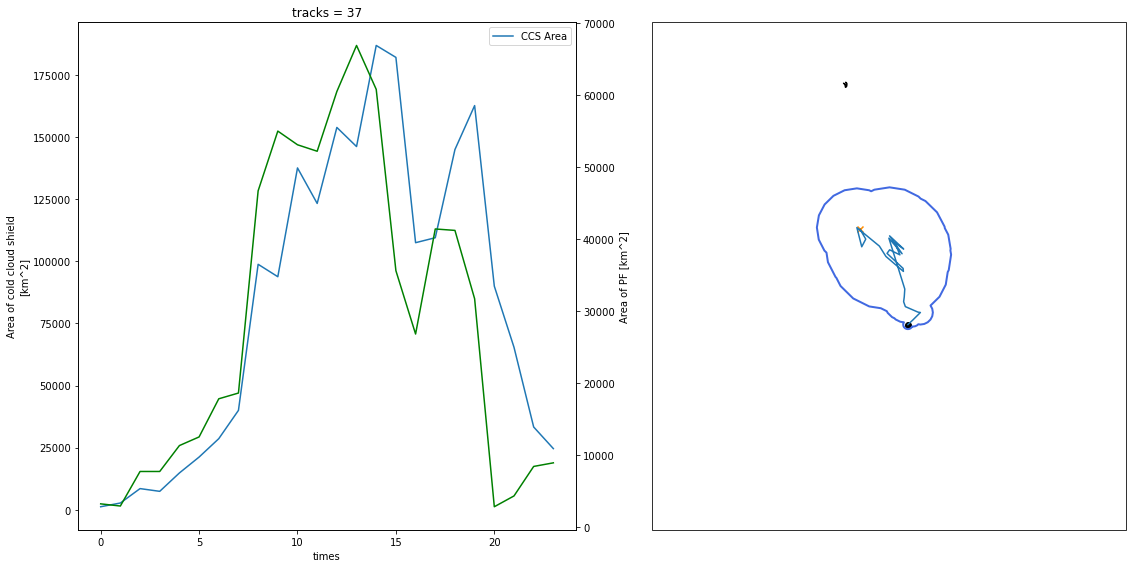

In [65]:
# Create a figure with 1 row and 2 columns
fig = plt.figure(figsize=(16, 8))

# Create left subplot (regular axis)
ax1 = fig.add_subplot(1, 2, 1)
track.ccs_area.plot(ax=ax1, label='CCS Area')
ax1b = ax1.twinx()
track.pf_area.isel(nmaxpf=0).plot(ax=ax1b, color='green', label='PF Area')
# ax1b.spines['right'].set_position(('outward', 60))  # Move the third y-axis to the right
# ax1b.invert_yaxis()
ax1b.set_title('')
ax1.legend()

# Create right subplot (with Cartopy projection)
# Use PlateCarree projection (equirectangular projection)
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())

ax2.coastlines()
ax2.add_feature(cf.BORDERS, linewidth=0.4)

ax2.scatter(track.meanlon.values[0], track.meanlat.values[0], marker='o', color='k')
ax2.scatter(track.meanlon.values[duration - 1], track.meanlat.values[duration - 1], marker='x', color='darkorange')
ax2.plot(track.meanlon.values, track.meanlat.values)
add_ccs_area_swath(ax2, track)
buffer = 8
extent = track.meanlon.min().item()-buffer, track.meanlon.max().item()+buffer, track.meanlat.min().item() - buffer, track.meanlat.max().item() + buffer
ax2.set_extent(extent)

fig.tight_layout()
# fig.tight_layout(rect=[0, 0.03, 1, 0.95])  # Make room for suptitle

In [66]:
def convert_to_cftime(datetime, calendar):
    """
    Convert a pandas.Timestamp object to a cftime object based on the calendar type.

    Args:
        datetime: pandas.Timestamp
            Timestamp object to convert.
        calendar: str
            Calendar type.

    Returns:
        cftime object.
    """
    if calendar == 'noleap':
        return cftime.DatetimeNoLeap(datetime.year, datetime.month, datetime.day, datetime.hour, datetime.minute)
    elif calendar == 'gregorian':
        return cftime.DatetimeGregorian(datetime.year, datetime.month, datetime.day, datetime.hour, datetime.minute)
    elif calendar == 'proleptic_gregorian':
        return cftime.DatetimeProlepticGregorian(datetime.year, datetime.month, datetime.day, datetime.hour, datetime.minute)
    elif calendar == 'standard':
        return cftime.DatetimeGregorian(datetime.year, datetime.month, datetime.day, datetime.hour, datetime.minute)
    elif calendar == '360_day':
        return cftime.Datetime360Day(datetime.year, datetime.month, datetime.day, datetime.hour, datetime.minute)
    else:
        raise ValueError(f"Unsupported calendar type: {calendar}")

In [67]:
# These can be used to work out which pixel-level data to locate the times.
calendar = ds['time'].dt.calendar

base_times = track.base_time.values[:duration]
track_dates = [convert_to_cftime(pd.Timestamp(d).to_pydatetime(), calendar) for d in base_times]
print(len(track_dates))
track_dates

24


[cftime.DatetimeProlepticGregorian(2020, 2, 1, 0, 0, 0, 0, has_year_zero=True),
 cftime.DatetimeProlepticGregorian(2020, 2, 1, 1, 0, 0, 0, has_year_zero=True),
 cftime.DatetimeProlepticGregorian(2020, 2, 1, 2, 0, 0, 0, has_year_zero=True),
 cftime.DatetimeProlepticGregorian(2020, 2, 1, 3, 0, 0, 0, has_year_zero=True),
 cftime.DatetimeProlepticGregorian(2020, 2, 1, 4, 0, 0, 0, has_year_zero=True),
 cftime.DatetimeProlepticGregorian(2020, 2, 1, 5, 0, 0, 0, has_year_zero=True),
 cftime.DatetimeProlepticGregorian(2020, 2, 1, 6, 0, 0, 0, has_year_zero=True),
 cftime.DatetimeProlepticGregorian(2020, 2, 1, 7, 0, 0, 0, has_year_zero=True),
 cftime.DatetimeProlepticGregorian(2020, 2, 1, 8, 0, 0, 0, has_year_zero=True),
 cftime.DatetimeProlepticGregorian(2020, 2, 1, 9, 0, 0, 0, has_year_zero=True),
 cftime.DatetimeProlepticGregorian(2020, 2, 1, 10, 0, 0, 0, has_year_zero=True),
 cftime.DatetimeProlepticGregorian(2020, 2, 1, 11, 0, 0, 0, has_year_zero=True),
 cftime.DatetimeProlepticGregorian(202

In [68]:
# Track number in the mask file is +1 offset to the track index in the stats file.
track_number = track.tracks + 1

In [69]:
# Increase the animation embed limit [MB]
mpl.rcParams['animation.embed_limit'] = 30

In [70]:
%%capture
# Prev line ensures figure not shown until animation.fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
# Set up a figure to use for the animation below.

margin_degree = 10
minlon = track.meanlon.values[:duration].min()
maxlon = track.meanlon.values[:duration].max()
minlat = track.meanlat.values[:duration].min()
maxlat = track.meanlat.values[:duration].max()
aspect = (maxlon - minlon + 2 * margin_degree) / (maxlat - minlat + 2 * margin_degree)
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
fig.set_size_inches((16, 16 / aspect))
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95)

In [71]:
# Create an animation of the track, MCS, OLR, and precip.
def plot_track_link_pixel(i):
    try:
        print(f'{i + 1}/{duration}')
        # print(f'{i}/{duration}')
        ax.clear()

        ax.set_extent((minlon - margin_degree, maxlon + margin_degree, minlat - margin_degree, maxlat + margin_degree))
        ax.coastlines(zorder=3)
        ax.add_feature(cf.BORDERS, linewidth=0.4, zorder=3)

        date = track_dates[i]
        ax.set_title(date)
        # Subset the HEALPix dataset to the current date & time
        _ds = ds.sel(time=track_dates[i], method='nearest')

        # Colormaps
        cmap_pr = mpl.colormaps.get_cmap('jet')
        cmap_rlut = mpl.colormaps.get_cmap('Greys')
        levels_pr = [0.5,1,2,4,8,16,32,64]
        norm = mpl.colors.BoundaryNorm(boundaries=levels_pr, ncolors=cmap_pr.N)
        # Precipitation
        _pr = _ds.pr * pcp_convert  # Convert unit to mm/hr
        _pr = _pr.where(_pr >= np.min(levels_pr), np.nan)
        # Mask
        _mask = _ds.mcs_mask.load()
        _mask = _mask.where(_mask == track_number, 1, 0)
        Zm_mask = np.ma.masked_where(_mask == 0, _mask)
        # Colorfill OLR and precipitation
        im_rlut = egh.healpix_show(_ds.rlut, ax=ax, vmin=80, vmax=260, cmap=cmap_rlut, alpha=0.7, zorder=1)
        im_pr = egh.healpix_show(_pr, ax=ax, cmap=cmap_pr, norm=norm, alpha=0.9, zorder=1)
        im_mask = egh.healpix_show(Zm_mask, ax=ax, cmap='Reds', vmin=1, vmax=1.01, alpha=0.5, zorder=2)
        # Contour MCS mask (boundary)
        # im_mask = egh.healpix_contour(_mask, ax=ax, levels=[0.5], colors=['r'], linewidths=1, alpha=1)
        buffer=8
        extent = track.meanlon.min().item()-buffer, track.meanlon.max().item()+buffer, track.meanlat.min().item() - buffer, track.meanlat.max().item() + buffer
        ax.set_extent(extent)
        
        # Display track path.
        ax.scatter(track.meanlon.values[0], track.meanlat.values[0], marker='^', c='maroon', zorder=3)
        ax.scatter(track.meanlon.values[duration - 1], track.meanlat.values[duration - 1], marker='x', c='maroon', zorder=3)
        ax.scatter(track.meanlon.values[i], track.meanlat.values[i], marker='o', c='firebrick', zorder=3)
        ax.plot(track.meanlon.values, track.meanlat.values, 'r-', zorder=2)
        # clear_output(wait=True)

        return ax
    except Exception as e:
        print(f"Error in frame {i}: {str(e)}")

In [72]:
# Create animation with specific settings
anim = matplotlib.animation.FuncAnimation(
    fig, 
    plot_track_link_pixel, 
    frames=duration,  # Number of frames
    # frames=2,
    interval=500,
    blit=False,  # Set to False for complex plots with multiple elements
    cache_frame_data=False  # Disable caching to avoid memory issues
)

anim

1/24
1/24
2/24
3/24
4/24
5/24
6/24
7/24
8/24
9/24
10/24
11/24
12/24
13/24
14/24
15/24
16/24
17/24
18/24
19/24
20/24
21/24
22/24
23/24
24/24


* Track: red line with circle showing its centroid.
* MCS mask: red shading.
* OLR: grey filled.
* precipitation: color filled contours.